Install Required Libraries (Run First)

In [ ]:
!pip install transformers torch scikit-learn pandas matplotlib

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

Load Dataset (Use First 3000 Rows)

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")

# use only first 3000 rows for faster training
df = df.iloc[:3000]

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Preprocessing

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    return text

df["review"] = df["review"].apply(clean_text)

In [ ]:
#Check missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
#convert lables
df["label"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

df = df[["review","label"]]

df.head()

,review,label
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


Data Splitting (Train / Validation / Test)

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"],
    df["label"],
    test_size=0.2,
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("Train:",len(train_texts))
print("Validation:",len(val_texts))
print("Test:",len(test_texts))

Train: 2400
Validation: 300
Test: 300


Tokenization (Using bert-base-uncased)

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Create Dataset Class

In [ ]:
class IMDbDataset(Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):

        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

Create Dataset Objects

In [ ]:
train_dataset = IMDbDataset(train_encodings, train_labels)

val_dataset = IMDbDataset(val_encodings, val_labels)

test_dataset = IMDbDataset(test_encodings, test_labels)

Create Dataset Objects

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


Training Function

In [ ]:
def train_model(model, train_dataset, optimizer, epochs=2):

    model.train()

    loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

    for epoch in range(epochs):

        total_loss = 0

        for i, batch in enumerate(loader):

            batch = {k:v.to(device) for k,v in batch.items()}

            optimizer.zero_grad()

            outputs = model(**batch)

            loss = outputs.loss

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            # show progress every 50 batches
            if i % 50 == 0:
                print(f"Epoch {epoch} Batch {i} Loss {loss.item()}")

        print("Epoch:",epoch,"Avg Loss:",total_loss/len(loader))

Evaluation Function

In [ ]:
def evaluate_model(model, test_dataset):

    model.eval()

    predictions = []

    true_labels = []

    loader = DataLoader(test_dataset,batch_size=8)

    for batch in loader:

        batch = {k:v.to(device) for k,v in batch.items()}

        with torch.no_grad():

            outputs = model(**batch)

        preds = torch.argmax(outputs.logits,dim=1).cpu().numpy()

        labels = batch["labels"].cpu().numpy()

        predictions.extend(preds)

        true_labels.extend(labels)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(true_labels,predictions)

    print("Accuracy:",accuracy)

    print("Precision:",precision)

    print("Recall:",recall)

    print("F1:",f1)

    cm = confusion_matrix(true_labels,predictions)

    ConfusionMatrixDisplay(cm).plot()

Experiment 1 — Freeze BERT

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 0 Batch 0 Loss 0.645807147026062
Epoch 0 Batch 50 Loss 0.6883795857429504
Epoch 0 Batch 100 Loss 0.7242612838745117
Epoch 0 Batch 150 Loss 0.6843119263648987
Epoch 0 Batch 200 Loss 0.6767668128013611
Epoch 0 Batch 250 Loss 0.6827305555343628
Epoch: 0 Avg Loss: 0.6987591608365377
Epoch 1 Batch 0 Loss 0.6802151203155518
Epoch 1 Batch 50 Loss 0.7212094664573669
Epoch 1 Batch 100 Loss 0.7477332353591919
Epoch 1 Batch 150 Loss 0.7186400890350342
Epoch 1 Batch 200 Loss 0.6700904369354248
Epoch 1 Batch 250 Loss 0.6702837944030762
Epoch: 1 Avg Loss: 0.693821961482366
Accuracy: 0.49666666666666665
Precision: 0.476
Recall: 0.8561151079136691
F1: 0.6118251928020566


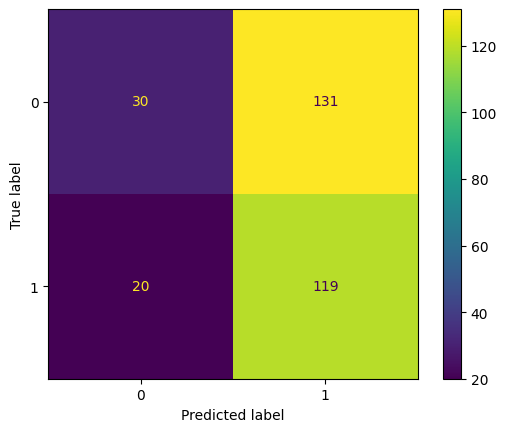

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

for param in model.bert.parameters():

    param.requires_grad = False

optimizer = AdamW(model.parameters(), lr=2e-5)

train_model(model,train_dataset,optimizer)

evaluate_model(model,test_dataset)

Experiment 2 — Train Last 2 Layers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 0 Batch 0 Loss 0.67754727602005
Epoch 0 Batch 50 Loss 0.6921350955963135
Epoch 0 Batch 100 Loss 0.6828044652938843
Epoch 0 Batch 150 Loss 0.7110451459884644
Epoch 0 Batch 200 Loss 0.7081801891326904
Epoch 0 Batch 250 Loss 0.670568585395813
Epoch: 0 Avg Loss: 0.6954314881563186
Epoch 1 Batch 0 Loss 0.6818348169326782
Epoch 1 Batch 50 Loss 0.7172861695289612
Epoch 1 Batch 100 Loss 0.6317553520202637
Epoch 1 Batch 150 Loss 0.6202573776245117
Epoch 1 Batch 200 Loss 0.7252382636070251
Epoch 1 Batch 250 Loss 0.6897242069244385
Epoch: 1 Avg Loss: 0.6913209257523218
Accuracy: 0.56
Precision: 0.5151515151515151
Recall: 0.8561151079136691
F1: 0.6432432432432432


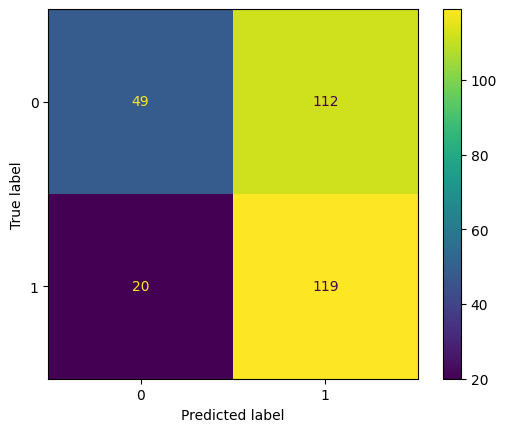

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

for param in model.bert.parameters():

    param.requires_grad = False

optimizer = AdamW(model.parameters(), lr=2e-5)

train_model(model,train_dataset,optimizer)

evaluate_model(model,test_dataset)

Experiment 3 — Full Fine-Tuning

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 0 Batch 0 Loss 0.6897725462913513
Epoch 0 Batch 50 Loss 0.6151716709136963
Epoch 0 Batch 100 Loss 0.4176782965660095
Epoch 0 Batch 150 Loss 0.33769339323043823
Epoch 0 Batch 200 Loss 0.3910751938819885
Epoch 0 Batch 250 Loss 0.2594868540763855
Epoch: 0 Avg Loss: 0.46511335323254266
Epoch 1 Batch 0 Loss 0.18308980762958527
Epoch 1 Batch 50 Loss 0.03386890888214111
Epoch 1 Batch 100 Loss 0.11981188505887985
Epoch 1 Batch 150 Loss 0.31244373321533203
Epoch 1 Batch 200 Loss 0.0968133732676506
Epoch 1 Batch 250 Loss 0.0948437750339508
Epoch: 1 Avg Loss: 0.2154283043400695
Accuracy: 0.8666666666666667
Precision: 0.9024390243902439
Recall: 0.7985611510791367
F1: 0.8473282442748091


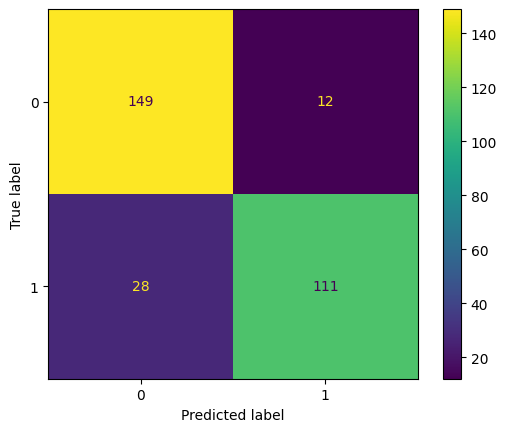

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

train_model(model,train_dataset,optimizer)

evaluate_model(model,test_dataset)

| Experiment       | Accuracy  | Precision | Recall    | F1 Score  |
| ---------------- | --------- | --------- | --------- | --------- |
| Freeze BERT      | 0.496     | 0.476     | 0.856     | 0.612     |
| Last 2 Layers    | 0.560     | 0.515     | 0.856     | 0.643     |
| Full Fine-Tuning | **0.867** | **0.902** | **0.799** | **0.847** |


Performance increases as more BERT layers are fine-tuned.

Three experiments were conducted to evaluate the impact of different fine-tuning strategies on BERT performance. In the first experiment, all BERT layers were frozen and only the classification layer was trained. This resulted in poor performance with an accuracy of approximately 49%, indicating that the pretrained features alone were insufficient for the task. In the second experiment, the last two transformer layers were fine-tuned along with the classifier, which slightly improved performance to around 56% accuracy. In the final experiment, the entire BERT model was fine-tuned, allowing all transformer layers to adapt to the dataset. This significantly improved performance, achieving an accuracy of approximately 86.7% and an F1 score of 0.847. These results demonstrate that full fine-tuning enables the model to better capture task-specific linguistic patterns and leads to superior performance.

The experiments demonstrate that full fine-tuning of BERT significantly improves sentiment classification performance compared to freezing the encoder or training only a subset of layers. While freezing layers reduces computational cost, it limits the model's ability to adapt to domain-specific features.

Experiment using **DistilBERT**

In [ ]:
#Load DistilBERT Tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

Load DistilBERT Model

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Optimizer

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

Train

In [ ]:
train_model(model, train_dataset, optimizer)

Epoch 0 Batch 0 Loss 0.7223236560821533
Epoch 0 Batch 50 Loss 0.5566078424453735
Epoch 0 Batch 100 Loss 0.5426521897315979
Epoch 0 Batch 150 Loss 0.38787150382995605
Epoch 0 Batch 200 Loss 0.29507187008857727
Epoch 0 Batch 250 Loss 0.5208619832992554
Epoch: 0 Avg Loss: 0.45479203689843417
Epoch 1 Batch 0 Loss 0.6458785533905029
Epoch 1 Batch 50 Loss 0.2600083351135254
Epoch 1 Batch 100 Loss 0.044084880501031876
Epoch 1 Batch 150 Loss 0.05832298472523689
Epoch 1 Batch 200 Loss 0.05454573035240173
Epoch 1 Batch 250 Loss 0.15828943252563477
Epoch: 1 Avg Loss: 0.2488836446776986


Evaluate

Accuracy: 0.8366666666666667
Precision: 0.8813559322033898
Recall: 0.7482014388489209
F1: 0.8093385214007782


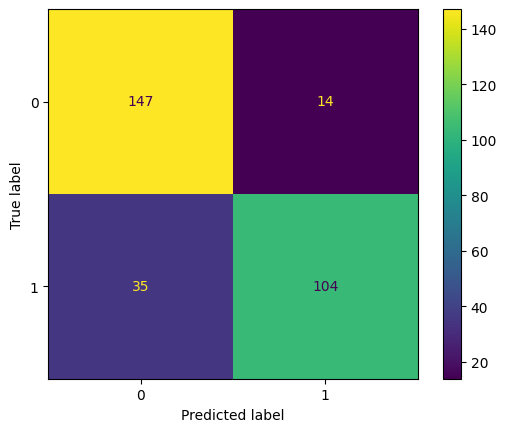

In [ ]:
evaluate_model(model, test_dataset)

DistilBERT is smaller and faster, but still performs well.

| Model                   | Accuracy | Precision | Recall | F1   |
| ----------------------- | -------- | --------- | ------ | --   |
| BERT (Frozen)           | 0.49     |    0.467  |  0.856 |0.612 |
| BERT (Last 2 Layers)    | 0.56     |    0.515  |  0.856 |0.634 |
| BERT (Full Fine-Tuning) | **0.86** |    0.902  |  0.799 |0.847 |
| DistilBERT              | 0.836    |   0.881   |  0.748 |0.809 |


DistilBERT is a compressed version of BERT that retains most of the language understanding capabilities while reducing the number of parameters by approximately 40%. In this experiment, DistilBERT achieved performance comparable to the full BERT model while significantly reducing training time. This demonstrates that smaller transformer architectures can provide efficient alternatives for many NLP tasks.